In [4]:
SIMULATION_DATE = "2026-06-08"

from config import r, STOCKS, FILEPATH, s3, EXCHANGE
import os

def download_file():
    local_path = f"{FILEPATH}/{EXCHANGE}/{STOCKS[0]}/{SIMULATION_DATE}.csv"
    if not os.path.exists(local_path):
        
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        try:
            s3.download_file(
                Bucket="cashcow",
                Key=f"{EXCHANGE}/{STOCKS[0]}/{SIMULATION_DATE}.csv",
                Filename=local_path
            )
            print(f"[MAIN] Downloaded {EXCHANGE}:{STOCKS[0]} for {SIMULATION_DATE}")
        except Exception as e:
            raise Exception(f"file not found, choose another date. key={EXCHANGE}/{STOCKS[0]}/{SIMULATION_DATE}.csv") from e
            

download_file()

In [5]:
from config import r 
r.flushall()

True

<Axes: >

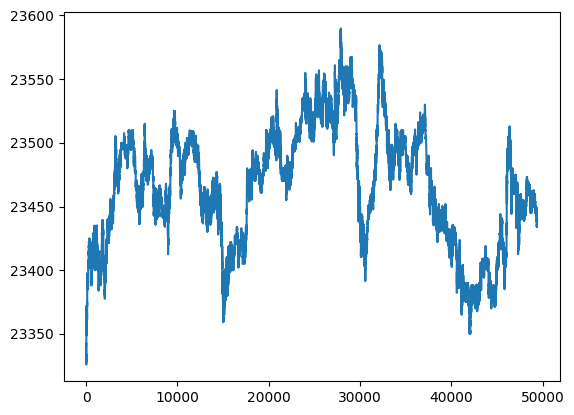

In [40]:
import pandas as pd
f = pd.read_csv(f"{FILEPATH}/{EXCHANGE}/{STOCKS[0]}/{SIMULATION_DATE}.csv")
f['last_price'].plot()


In [5]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from simulator import get_all_tick_data
df = get_all_tick_data(SIMULATION_DATE)
from StockAnalyser import Delta_analysis
instance = Delta_analysis()
size = len(df)
print(len(df))
for _, row in tqdm(df[:size].iterrows(), total=size, desc="Parsing ticks"):
    instance.parse(row.to_dict())

✅ Cache is up to date, no refresh needed
[INFO] loaded data into memory for simulation
25249


Parsing ticks: 100%|██████████| 25249/25249 [00:01<00:00, 16113.67it/s]


<Axes: >

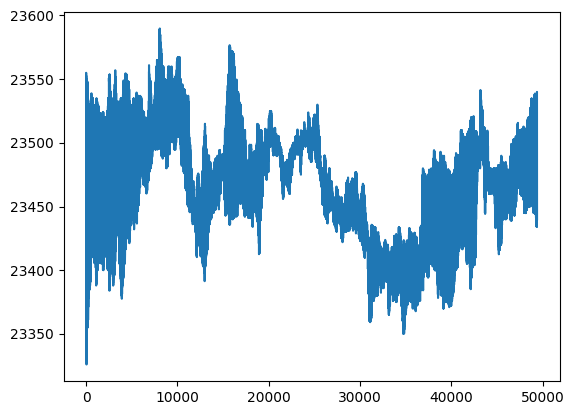

In [ ]:
df['last_price']

In [35]:
instance.ltpdf[0:]

array([[2.35500996e+04, 1.61200000e+04, 0.00000000e+00, 0.00000000e+00],
       [2.35500000e+04, 7.15000000e+02, 0.00000000e+00, 0.00000000e+00],
       [2.33419004e+04, 0.00000000e+00, 8.00150000e+04, 1.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(40000, 4))

In [ ]:
import numpy as np
import pyqtgraph as pg
from PyQt5.QtCore import QRectF, Qt


def get_active_price_bounds_local(inst):
    active = np.where((inst.aggdf_buy > 0) & (inst.aggdf_sell > 0))[0]
    if active.size == 0:
        return 0, max(0, inst.WIDTH - 1)
    return int(active[0]), int(active[-1])


def make_component_map(arr, true_code):
    out = np.zeros_like(arr, dtype=np.uint8)  # default 0 => red
    valid = ~np.isnan(arr)
    out[valid] = np.where(arr[valid] >= 0, true_code, 0).astype(np.uint8)
    out[~valid] = 16  # transparent
    return out


def active_bounds_series(arr, min_idx, base_ltp):
    """Return per-row min/max active LTP lines for a component array."""
    price_axis = base_ltp + np.arange(min_idx, min_idx + arr.shape[1], dtype=float)
    active = (~np.isnan(arr)) & (arr >= 0)

    min_series = np.full(arr.shape[0], np.nan, dtype=float)
    max_series = np.full(arr.shape[0], np.nan, dtype=float)

    valid_rows = np.any(active, axis=1)
    if np.any(valid_rows):
        per_row_prices = np.where(active, price_axis[np.newaxis, :], np.nan)
        min_series[valid_rows] = np.nanmin(per_row_prices[valid_rows], axis=1)
        max_series[valid_rows] = np.nanmax(per_row_prices[valid_rows], axis=1)

    return min_series, max_series


def first_order_diff(series):
    """Difference between the current and immediate previous value."""
    series = np.asarray(series, dtype=float)
    return np.diff(series, prepend=np.nan)


# A "spike" is a first-order diff whose magnitude exceeds this many points.
SPIKE_THRESHOLD = 5.0
# One distinct colour per signal, for spike markers on the combined graph.
SPIKE_COLORS = [
    (220, 20, 60),    # hl_buy  - crimson
    (255, 140, 0),    # lh_buy  - orange
    (148, 0, 211),    # hl_sell - purple
    (0, 180, 180),    # lh_sell - teal
]


# ---------- Build heatmap data ----------
rows_used = int(instance.curr_time_idx)
if rows_used <= 0:
    raise ValueError("No parsed ticks available in instance.")

min_idx, max_idx = get_active_price_bounds_local(instance)
col_slice = slice(min_idx, max_idx + 1)

lh_buy = instance.lowHigh['buy'][:rows_used, col_slice]
hl_buy = instance.highLow['buy'][:rows_used, col_slice]
lh_sell = instance.lowHigh['sell'][:rows_used, col_slice]
hl_sell = instance.highLow['sell'][:rows_used, col_slice]

valid_buy = ~np.isnan(lh_buy)
valid_sell = ~np.isnan(lh_sell)

buy_code = np.zeros_like(lh_buy, dtype=np.uint8)
sell_code = np.zeros_like(lh_sell, dtype=np.uint8)

buy_code[valid_buy] = (
    (lh_buy[valid_buy] >= 0).astype(np.uint8)
    + 2 * (hl_buy[valid_buy] >= 0).astype(np.uint8)
)
sell_code[valid_sell] = (
    (lh_sell[valid_sell] >= 0).astype(np.uint8)
    + 2 * (hl_sell[valid_sell] >= 0).astype(np.uint8)
)

heatmap_data = sell_code + 4 * buy_code
invalid = ~(valid_buy & valid_sell)
heatmap_data[invalid] = 16  # transparent

# ---------- LUT ----------
base_lut = np.array([
    [255, 0, 0, 170],       # 0: Red
    [0, 114, 178, 170],     # 1: Blue
    [230, 159, 0, 170],     # 2: Orange
    [86, 180, 233, 170],    # 3: Sky Blue
    [0, 158, 115, 170],     # 4: Bluish Green
    [204, 121, 167, 170],   # 5: Purple
    [240, 228, 66, 170],    # 6: Yellow
    [0, 0, 128, 170],       # 7: Navy
    [255, 105, 180, 170],   # 8: Pink,
    [27, 94, 32, 170],      # 9: Dark Green
    [139, 69, 19, 170],     # 10: Brown
    [128, 0, 0, 170],       # 11: Maroon
    [0, 128, 128, 170],     # 12: Teal
    [245, 245, 245, 170],   # 13: Off-White
    [119, 119, 119, 170],   # 14: Gray
    [57, 255, 20, 170],     # 15: Neon Green
    [0, 0, 0, 0],           # 16: TRANSPARENT
], dtype=np.ubyte)

full_lut = np.zeros((256, 4), dtype=np.ubyte)
full_lut[:17] = base_lut

min_ltp = float(instance.base_ltp + min_idx)
max_ltp = float(instance.base_ltp + max_idx)
rect = QRectF(0, min_ltp, rows_used, max(1.0, max_ltp - min_ltp + 1.0))

# ---------- App ----------
app = pg.mkQApp("Delta Analysis Heatmaps")

# Window 1: Combined
win_combined = pg.GraphicsLayoutWidget(title="Delta Analysis - Combined")
win_combined.setBackground("white")
p_combined = win_combined.addPlot(title="Combined State (0..15)")
p_combined.showGrid(x=True, y=True, alpha=0.15)

img_combined = pg.ImageItem()
img_combined.setLookupTable(full_lut)
img_combined.setImage(heatmap_data, autoLevels=False)
img_combined.setRect(rect)
p_combined.addItem(img_combined)

ltp_values = instance.ltpdf[:rows_used, 0].astype(float)
valid_ltp = np.isfinite(ltp_values) & (ltp_values != 0)
x = np.arange(rows_used, dtype=float)[valid_ltp]
y = ltp_values[valid_ltp]
p_combined.plot(x, y, pen=pg.mkPen(color=(0, 0, 255), width=2), name="LTP")

p_combined.setLabel("left", "LTP")
p_combined.setLabel("bottom", "Tick Index")
p_combined.setYRange(min_ltp, max_ltp, padding=0)
win_combined.show()

# Window 2: Components (heatmaps)
win_components = pg.GraphicsLayoutWidget(title="Delta Analysis - Components")
win_components.setBackground("white")

# Window 3: Stats (separate window)
win_stats = pg.GraphicsLayoutWidget(title="Delta Analysis - Stats")
win_stats.setBackground("white")

# Spike markers on the combined ("main") graph: one colour per signal.
spike_legend = p_combined.addLegend(offset=(10, 10))

# Bit-consistent mapping from combined formula:
# hl_buy=8, lh_buy=4, hl_sell=2, lh_sell=1
component_specs = [
    ("hl_buy (0 / 8 / transparent)", hl_buy, 8),
    ("lh_buy (0 / 4 / transparent)", lh_buy, 4),
    ("hl_sell (0 / 2 / transparent)", hl_sell, 2),
    ("lh_sell (0 / 1 / transparent)", lh_sell, 1),
]

plots = []
for i, (title, arr, true_code) in enumerate(component_specs):
    row, col = divmod(i, 2)
    main_row = row * 2

    # Component heatmap plot (in win_components)
    p = win_components.addPlot(row=main_row, col=col, title=title)
    p.showGrid(x=True, y=True, alpha=0.15)

    img = pg.ImageItem()
    img.setLookupTable(full_lut)
    img.setImage(make_component_map(arr, true_code), autoLevels=False)
    img.setRect(rect)
    p.addItem(img)

    p.setLabel("left", "LTP")
    p.setLabel("bottom", "Tick Index")
    p.setYRange(min_ltp, max_ltp, padding=0)
    plots.append(p)

    # Plot LTP on each component plot so users can compare directly
    try:
        p.plot(x, y, pen=pg.mkPen(color=(0, 0, 255), width=2), name="LTP")
    except Exception:
        pass

    # Add min/max LH/HL boundary lines on each multigraph
    try:
        min_line, max_line = active_bounds_series(arr[:rows_used, :], min_idx, instance.base_ltp)
        row_x = np.arange(rows_used, dtype=float)

        valid_min = np.isfinite(min_line)
        valid_max = np.isfinite(max_line)

        if np.any(valid_min):
            p.plot(
                row_x[valid_min],
                min_line[valid_min],
                pen=pg.mkPen(color=(128, 0, 128), width=4.0),
                name="Min LH/HL",
            )
        if np.any(valid_max):
            p.plot(
                row_x[valid_max],
                max_line[valid_max],
                pen=pg.mkPen(color=(0, 0, 0), width=4.0),
                name="Max LH/HL",
            )
    except Exception:
        pass

    # Stats plot in separate window: Max/Mean/Min and first-order MAD signal
    try:
        arr_slice = arr[:rows_used, :].astype(float)
        row_max = np.nanmax(arr_slice, axis=1)
        row_mean = np.nanmean(arr_slice, axis=1)
        row_min = np.nanmin(arr_slice, axis=1)

        valid_vals = np.isfinite(row_max) | np.isfinite(row_mean) | np.isfinite(row_min)
        if np.any(valid_vals):
            x_vals = np.arange(rows_used, dtype=float)[valid_vals]
            y_max = row_max[valid_vals]
            y_mean = row_mean[valid_vals]
            y_min = row_min[valid_vals]

            yr_min = np.nanmin(np.stack([y_min, y_mean, y_max]))
            yr_max = np.nanmax(np.stack([y_min, y_mean, y_max]))

            sp = win_stats.addPlot(row=row * 2, col=col, title=title + " - Max/Mean/Min")
            sp.showGrid(x=True, y=True, alpha=0.15)

            sp.plot(x_vals, y_max, pen=pg.mkPen(color=(0, 0, 255), width=2), name="Max")
            sp.plot(x_vals, y_mean, pen=pg.mkPen(color=(0, 200, 0), width=2), name="Mean")
            sp.plot(x_vals, y_min, pen=pg.mkPen(color=(255, 200, 0), width=2), name="Min")

            sp.setLabel("left", "Value")
            sp.setLabel("bottom", "Tick Index")

            if np.isfinite(yr_min) and np.isfinite(yr_max) and yr_max > yr_min:
                sp.setYRange(float(yr_min), float(yr_max), padding=0)

            sp.setXLink(p)

            # Signal plot for the three stats lines
            sig_max = first_order_diff(row_max)
            sig_mean = first_order_diff(row_mean)
            sig_min = first_order_diff(row_min)

            # Mark ticks where the max d1 spikes by more than SPIKE_THRESHOLD
            # points on the combined LTP graph, colour-coded per signal.
            spike = (np.abs(sig_max) > SPIKE_THRESHOLD) & valid_ltp
            spike_idx = np.nonzero(spike)[0]
            spike_sc = pg.ScatterPlotItem(
                x=spike_idx.astype(float), y=ltp_values[spike_idx],
                size=12, symbol="o",
                brush=pg.mkBrush(*SPIKE_COLORS[i]),
                pen=pg.mkPen(color=(0, 0, 0, 150), width=0.5),
            )
            p_combined.addItem(spike_sc)
            spike_legend.addItem(spike_sc, f"{title} spike")

            #valid_sig = np.isfinite(sig_max) | np.isfinite(sig_mean) | np.isfinite(sig_min)
            valid_sig = np.isfinite(sig_mean) | np.isfinite(sig_min)
            if np.any(valid_sig):
                sx = np.arange(rows_used, dtype=float)[valid_sig]
                sp_sig = win_stats.addPlot(row=row * 2 + 1, col=col, title=title + " - d1 Signal")
                sp_sig.showGrid(x=True, y=True, alpha=0.15)

                #sp_sig.plot(sx, sig_max[valid_sig], pen=pg.mkPen(color=(0, 0, 255), width=2), name="Max Signal")
                sp_sig.plot(sx, sig_mean[valid_sig], pen=pg.mkPen(color=(0, 200, 0), width=2), name="Mean Signal")
                sp_sig.plot(sx, sig_min[valid_sig], pen=pg.mkPen(color=(255, 200, 0), width=2), name="Min Signal")

                sp_sig.addLine(y=0, pen=pg.mkPen(color=(120, 120, 120), width=1, style=Qt.DashLine))
                sp_sig.setLabel("left", "Diff")
                sp_sig.setLabel("bottom", "Tick Index")
                sp_sig.setXLink(p)
    except Exception:
        pass

# Sync all top component plots' ranges to the first component
master = plots[0]
for p in plots[1:]:
    p.setXLink(master)
    p.setYLink(master)

all_plots = [p_combined] + plots
_sync_guard = {"busy": False}


def _sync_ranges(src_vb, ranges):
    if _sync_guard["busy"]:
        return
    _sync_guard["busy"] = True
    try:
        (x0, x1), (y0, y1) = ranges
        for p in all_plots:
            vb = p.getViewBox()
            if vb is src_vb:
                continue
            vb.setXRange(x0, x1, padding=0)
            vb.setYRange(y0, y1, padding=0)
    finally:
        _sync_guard["busy"] = False

for p in all_plots:
    p.getViewBox().sigRangeChanged.connect(_sync_ranges)

win_components.show()
win_stats.show()
app.exec()

/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:215: RuntimeWarning: All-NaN slice encountered
  row_max = np.nanmax(arr_slice, axis=1)
/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:216: RuntimeWarning: Mean of empty slice
  row_mean = np.nanmean(arr_slice, axis=1)
/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:217: RuntimeWarning: All-NaN slice encountered
  row_min = np.nanmin(arr_slice, axis=1)
/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:215: RuntimeWarning: All-NaN slice encountered
  row_max = np.nanmax(arr_slice, axis=1)
/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:216: RuntimeWarning: Mean of empty slice
  row_mean = np.nanmean(arr_slice, axis=1)
/var/folders/v8/1wyl6_ks02s620m7tv5drmch0000gn/T/ipykernel_99475/1890029492.py:217: RuntimeWarning: All-NaN slice encountered
  row_min = np.nanmin(arr_slice, axis=1)


In [6]:
# Generate CSV Files for each component
output_dir = f"{FILEPATH}/delta_components/{EXCHANGE}/{STOCKS[0]}/{SIMULATION_DATE}"
os.makedirs(output_dir, exist_ok=True)
np.savetxt(f"{output_dir}/hl_buy.csv", hl_buy, delimiter=",", fmt="%s")
np.savetxt(f"{output_dir}/lh_buy.csv", lh_buy, delimiter=",", fmt="%s")
np.savetxt(f"{output_dir}/hl_sell.csv", hl_sell, delimiter=",", fmt="%s")
np.savetxt(f"{output_dir}/lh_sell.csv", lh_sell, delimiter=",", fmt="%s")   

# Old Versions- don't bother with these :D

In [3]:
import numpy as np
import pyqtgraph as pg
from PyQt5.QtCore import QRectF

def get_active_price_bounds_local(inst):
    active = np.where((inst.aggdf_buy > 0) & (inst.aggdf_sell > 0))[0]
    if active.size == 0:
        return 0, max(0, inst.WIDTH - 1)
    return int(active[0]), int(active[-1])

# ---------- Build heatmap data from Delta_analysis numpy arrays ----------
rows_used = int(instance.curr_time_idx)
if rows_used <= 0:
    raise ValueError("No parsed ticks available in instance.")

min_idx, max_idx = get_active_price_bounds_local(instance)
col_slice = slice(min_idx, max_idx + 1)

# 1. Extract matrices
lh_buy = instance.lowHigh['buy'][:rows_used, col_slice]
hl_buy = instance.highLow['buy'][:rows_used, col_slice]
lh_sell = instance.lowHigh['sell'][:rows_used, col_slice]
hl_sell = instance.highLow['sell'][:rows_used, col_slice]

# 2. Find where data is valid (Not NaN)
valid_buy = ~np.isnan(lh_buy)
valid_sell = ~np.isnan(lh_sell)

# 3. Calculate codes cleanly as integers
buy_code = np.zeros_like(lh_buy, dtype=np.uint8)
sell_code = np.zeros_like(lh_sell, dtype=np.uint8)

buy_code[valid_buy] = (
    (lh_buy[valid_buy] >= 0).astype(np.uint8)
    + 2 * (hl_buy[valid_buy] >= 0).astype(np.uint8)
)

sell_code[valid_sell] = (
    (lh_sell[valid_sell] >= 0).astype(np.uint8)
    + 2 * (hl_sell[valid_sell] >= 0).astype(np.uint8)
)

# 4. Combine into strict integers (0 to 15)
heatmap_data = sell_code + 4 * buy_code

# 5. If EITHER buy or sell is missing, the pixel is transparent
invalid = ~(valid_buy & valid_sell)
heatmap_data[invalid] = 16

# ---------- PyQtGraph setup ----------
app = pg.mkQApp("Delta Analysis Heatmap")
win = pg.GraphicsLayoutWidget(title="Delta_analysis Heatmap & LTP")
win.setBackground("white")

# 17 Base Colors
base_lut = np.array([
    [255, 0, 0, 170],       # 0: Red
    [0, 114, 178, 170],     # 1: Blue
    [230, 159, 0, 170],     # 2: Orange
    [86, 180, 233, 170],    # 3: Sky Blue
    [0, 158, 115, 170],     # 4: Bluish Green
    [204, 121, 167, 170],   # 5: Purple
    [240, 228, 66, 170],    # 6: Yellow
    [0, 0, 128, 170],       # 7: Navy
    [255, 105, 180, 170],   # 8: Pink
    [27, 94, 32, 170],      # 9: Dark Green
    [139, 69, 19, 170],     # 10: Brown
    [128, 0, 0, 170],       # 11: Maroon
    [0, 128, 128, 170],     # 12: Teal
    [245, 245, 245, 170],   # 13: Off-White
    [119, 119, 119, 170],   # 14: Gray
    [57, 255, 20, 170],     # 15: Neon Green
    [0, 0, 0, 0],           # 16: TRANSPARENT (Background)
], dtype=np.ubyte)

# Pad LUT to exactly 256 rows so PyQtGraph does direct indexing
full_lut = np.zeros((256, 4), dtype=np.ubyte)
full_lut[:17] = base_lut

min_ltp = float(instance.base_ltp + min_idx)
max_ltp = float(instance.base_ltp + max_idx)
rect = QRectF(0, min_ltp, rows_used, max(1.0, max_ltp - min_ltp + 1.0))

# --- Plot 1: Combined ---
plot_combined = win.addPlot(title="Combined State (0..15)")
plot_combined.showGrid(x=True, y=True, alpha=0.15)
img_combined = pg.ImageItem()
img_combined.setLookupTable(full_lut)
img_combined.setImage(heatmap_data, autoLevels=False)
img_combined.setRect(rect)
plot_combined.addItem(img_combined)

ltp_values = instance.ltpdf[:rows_used, 0].astype(float)
valid_ltp = np.isfinite(ltp_values) & (ltp_values != 0)
x = np.arange(rows_used, dtype=float)[valid_ltp]
y = ltp_values[valid_ltp]
plot_combined.plot(x, y, pen=pg.mkPen(color=(0, 0, 255), width=2), name="LTP")
plot_combined.setLabel("left", "LTP")
plot_combined.setYRange(min_ltp, max_ltp, padding=0)

def make_component_map(arr, true_code):
    out = np.zeros_like(arr, dtype=np.uint8)  # default 0 => red
    valid = ~np.isnan(arr)
    out[valid] = np.where(arr[valid] >= 0, true_code, 0).astype(np.uint8)
    out[~valid] = 16  # transparent
    return out

# Bit-consistent mapping from combined formula:
# hl_buy=8, lh_buy=4, hl_sell=2, lh_sell=1
component_specs = [
    ("hl_buy (0 / 8 / transparent)", hl_buy, 8),
    ("lh_buy (0 / 4 / transparent)", lh_buy, 4),
    ("hl_sell (0 / 2 / transparent)", hl_sell, 2),
    ("lh_sell (0 / 1 / transparent)", lh_sell, 1),
]

for title, arr, true_code in component_specs:
    win.nextRow()
    p = win.addPlot(title=title)
    p.showGrid(x=True, y=True, alpha=0.15)
    p.setXLink(plot_combined)
    p.setYLink(plot_combined)
    img = pg.ImageItem()
    img.setLookupTable(full_lut)
    img.setImage(make_component_map(arr, true_code), autoLevels=False)
    img.setRect(rect)
    p.addItem(img)
    p.setLabel("left", "LTP")
    p.setLabel("bottom", "Tick Index")
    # Plot LTP on this component plot as well
    try:
        p.plot(x, y, pen=pg.mkPen(color=(0, 0, 255), width=2), name="LTP")
    except Exception:
        pass

    # Compute and plot max active price index per-row on right axis
    try:
        cols = np.arange(min_idx, max_idx + 1)
        valid_mask = ~np.isnan(arr[:rows_used, :])
        if valid_mask.shape[1] == cols.size:
            idxs = np.where(valid_mask, cols[np.newaxis, :], -999999)
            max_idx_per_row = np.max(idxs, axis=1)
            max_idx_per_row[max_idx_per_row < 0] = np.nan
            max_ltp_vals = instance.base_ltp + max_idx_per_row

            valid_max = np.isfinite(max_ltp_vals)
            x_max = np.arange(rows_used, dtype=float)[valid_max]
            y_max = max_ltp_vals[valid_max]

            p.showAxis('right')
            p.getAxis('right').setLabel('Max LTP')
            vb2 = pg.ViewBox()
            p.scene().addItem(vb2)
            p.getAxis('right').linkToView(vb2)
            vb2.setXLink(p.getViewBox())
            vb2.setYRange(min_ltp, max_ltp, padding=0)

            max_curve = pg.PlotCurveItem(x_max, y_max, pen=pg.mkPen(color=(200, 0, 0), width=2), name="Max")
            vb2.addItem(max_curve)

            def _update_views(vb=p.getViewBox(), vb2=vb2):
                vb2.setGeometry(vb.sceneBoundingRect())
                vb2.linkedViewChanged(vb, vb.YAxis)

            p.getViewBox().sigResized.connect(_update_views)
            _update_views()
    except Exception:
        pass

plot_combined.setLabel("bottom", "Tick Index")
win.show()
app.exec()

0